In [ ]:
# ==========================================
# Task 1: Environment Setup and Data Loading
# ==========================================
import torch
import torchvision
from torchvision import models, transforms
from torchvision.models import (
    ResNet18_Weights,
    MobileNet_V3_Small_Weights,
    EfficientNet_B0_Weights,
)
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
import time
import random
import copy
import os
from pathlib import Path
from sklearn.decomposition import PCA
import pandas as pd

os.makedirs("outputs", exist_ok=True)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# NOTE: Adjust this path if your Kaggle folder structure requires it!
DATA_DIR = Path("/kaggle/input/intel-image-classification/seg_test/seg_test")
LABELS   = ["buildings", "forest", "glacier", "mountain", "sea", "street"]
random.seed(42)

def load_images(n_per_class=10):
    """Load n images per class. Returns a list of (PIL.Image, label_string) tuples."""
    image_set = []
    for label in LABELS:
        class_dir = DATA_DIR / label
        paths = random.sample(list(class_dir.glob("*.jpg")), n_per_class)
        for path in paths:
            img = Image.open(path).convert("RGB")
            image_set.append((img, label))
    random.shuffle(image_set)
    return image_set

image_set = load_images(n_per_class=10)
print(f"Total images loaded: {len(image_set)}")

# Display a 2x3 grid
fig, axes = plt.subplots(2, 3, figsize=(12, 8))
# Grab one of each label
sample_dict = {label: next(img for img, l in image_set if l == label) for label in LABELS}

for ax, (label, img) in zip(axes.flatten(), sample_dict.items()):
    ax.imshow(img)
    ax.set_title(label.capitalize(), fontsize=14)
    ax.axis('off')

plt.tight_layout()
plt.savefig("outputs/dataset_sample.png")
plt.clf()
print("Saved outputs/dataset_sample.png")

"""
COMMENT: Does that mean a pretrained ImageNet model is a poor fit for this data, or a reasonable starting point? Why?
Good starting point. Even though ImageNet is 1,000 highly 
specific classes, the foundational layers of the model have learned universal 
visual features: edges, gradients, textures, skies, and foliage. Also, 
ImageNet contains enough outdoor scenes (like "valley" or "alp") that it overlaps heavily with our six categories.
"""

Using device: cuda
Total images loaded: 60
Saved outputs/dataset_sample.png


'\nCOMMENT: Does that mean a pretrained ImageNet model is a poor fit for this data, or a reasonable starting point? Why?\nGood starting point. Even though ImageNet is 1,000 highly \nspecific classes, the foundational layers of the model have learned universal \nvisual features: edges, gradients, textures, skies, and foliage. Also, \nImageNet contains enough outdoor scenes (like "valley" or "alp") that it overlaps heavily with our six categories.\n'

<Figure size 1200x800 with 0 Axes>

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 208MB/s]


ResNet18 parameters: 11,689,512
Processed 60 images.

Overall Mean Top-1 Probability: 0.4195

Mean Top-1 Probability by Class:
true_label
sea          0.571034
mountain     0.555562
glacier      0.499333
street       0.354364
buildings    0.288908
forest       0.247658
Name: top1_prob, dtype: float64


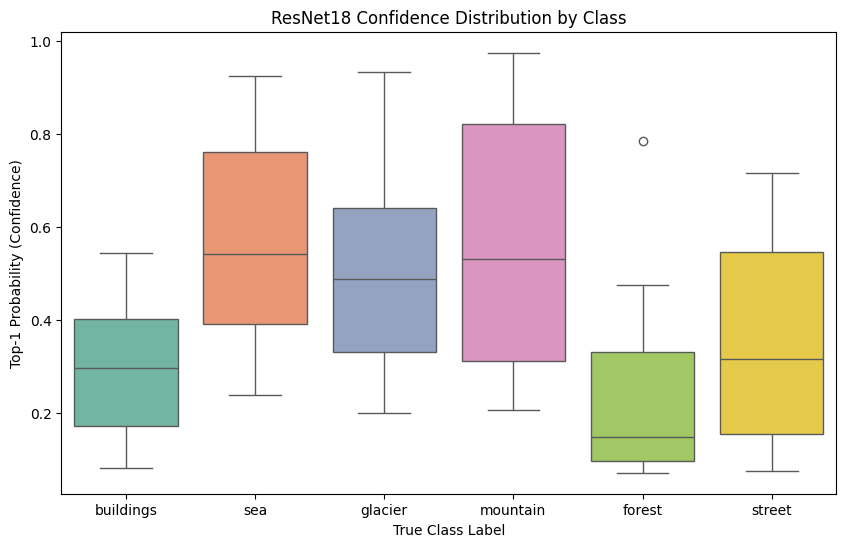

"\nCOMMENT: High confidence and high accuracy are not the same thing. How would you use confidence scores?\nIn a production confidence scores are used as a triage mechanism. \nIf the model's top prediction is over a certain threshold (e.g., 85%), the system \nautomatically tags the photo and moves on. If the probability is lower than that \nthreshold, it suggests the model is confused (perhaps it's a blurry photo or a \nglacier that looks like the sea). In those cases, the image is flagged and routed \ninto a queue for a human reviewer to manually tag.\n"

In [2]:
# ==========================================
# Task 2: Baseline Inference with ResNet18
# ==========================================
import seaborn as sns

resnet_weights   = ResNet18_Weights.DEFAULT
resnet           = models.resnet18(weights=resnet_weights).to(device).eval()
resnet_preproc   = resnet_weights.transforms()
imagenet_classes = resnet_weights.meta["categories"]
print(f"ResNet18 parameters: {sum(p.numel() for p in resnet.parameters()):,}")

def run_inference(model, preprocess, img, device, class_labels, top_k=5):
    """Runs inference and returns a list of (class_name, probability) tuples."""
    tensor = preprocess(img).unsqueeze(0).to(device)
    with torch.no_grad():
        output = model(tensor)
    probs = torch.nn.functional.softmax(output[0], dim=0)
    top_probs, top_indices = torch.topk(probs, top_k)
    return [(class_labels[idx.item()], prob.item()) for prob, idx in zip(top_probs, top_indices)]

# Run inference on all 60 images
resnet_results = []
for img, true_label in image_set:
    preds = run_inference(resnet, resnet_preproc, img, device, imagenet_classes)
    resnet_results.append({
        "true_label":   true_label,
        "top1_class":   preds[0][0],
        "top1_prob":    preds[0][1],
        "top5_classes": [p[0] for p in preds],
        "top5_probs":   [p[1] for p in preds],
    })

print(f"Processed {len(resnet_results)} images.\n")

# Convert to DataFrame for easy analysis
df_resnet = pd.DataFrame(resnet_results)

# 1. Overall mean top-1 probability
print(f"Overall Mean Top-1 Probability: {df_resnet['top1_prob'].mean():.4f}")

# 2. Mean top-1 probability broken down by true class
print("\nMean Top-1 Probability by Class:")
print(df_resnet.groupby('true_label')['top1_prob'].mean().sort_values(ascending=False))

# 3. Create Boxplot
plt.figure(figsize=(10, 6))

# Added hue and legend=False to fix the seaborn warning!
sns.boxplot(data=df_resnet, x='true_label', y='top1_prob', hue='true_label', palette='Set2', legend=False)

plt.title('ResNet18 Confidence Distribution by Class')
plt.xlabel('True Class Label')
plt.ylabel('Top-1 Probability (Confidence)')

plt.savefig('outputs/resnet18_confidence_by_class.png')
plt.show() # Replaced plt.clf() with plt.show() so you can see it inline!
"""
COMMENT: High confidence and high accuracy are not the same thing. How would you use confidence scores?
In a production confidence scores are used as a triage mechanism. 
If the model's top prediction is over a certain threshold (e.g., 85%), the system 
automatically tags the photo and moves on. If the probability is lower than that 
threshold, it suggests the model is confused (perhaps it's a blurry photo or a 
glacier that looks like the sea). In those cases, the image is flagged and routed 
into a queue for a human reviewer to manually tag.
"""

Downloading: "https://download.pytorch.org/models/mobilenet_v3_small-047dcff4.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v3_small-047dcff4.pth


100%|██████████| 9.83M/9.83M [00:00<00:00, 179MB/s]


Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 209MB/s]


--- Parameter Counts ---
ResNet18                  11,689,512 parameters
MobileNetV3-Small          2,542,856 parameters
EfficientNet-B0            5,288,548 parameters

Saved outputs/model_comparison_grid.png


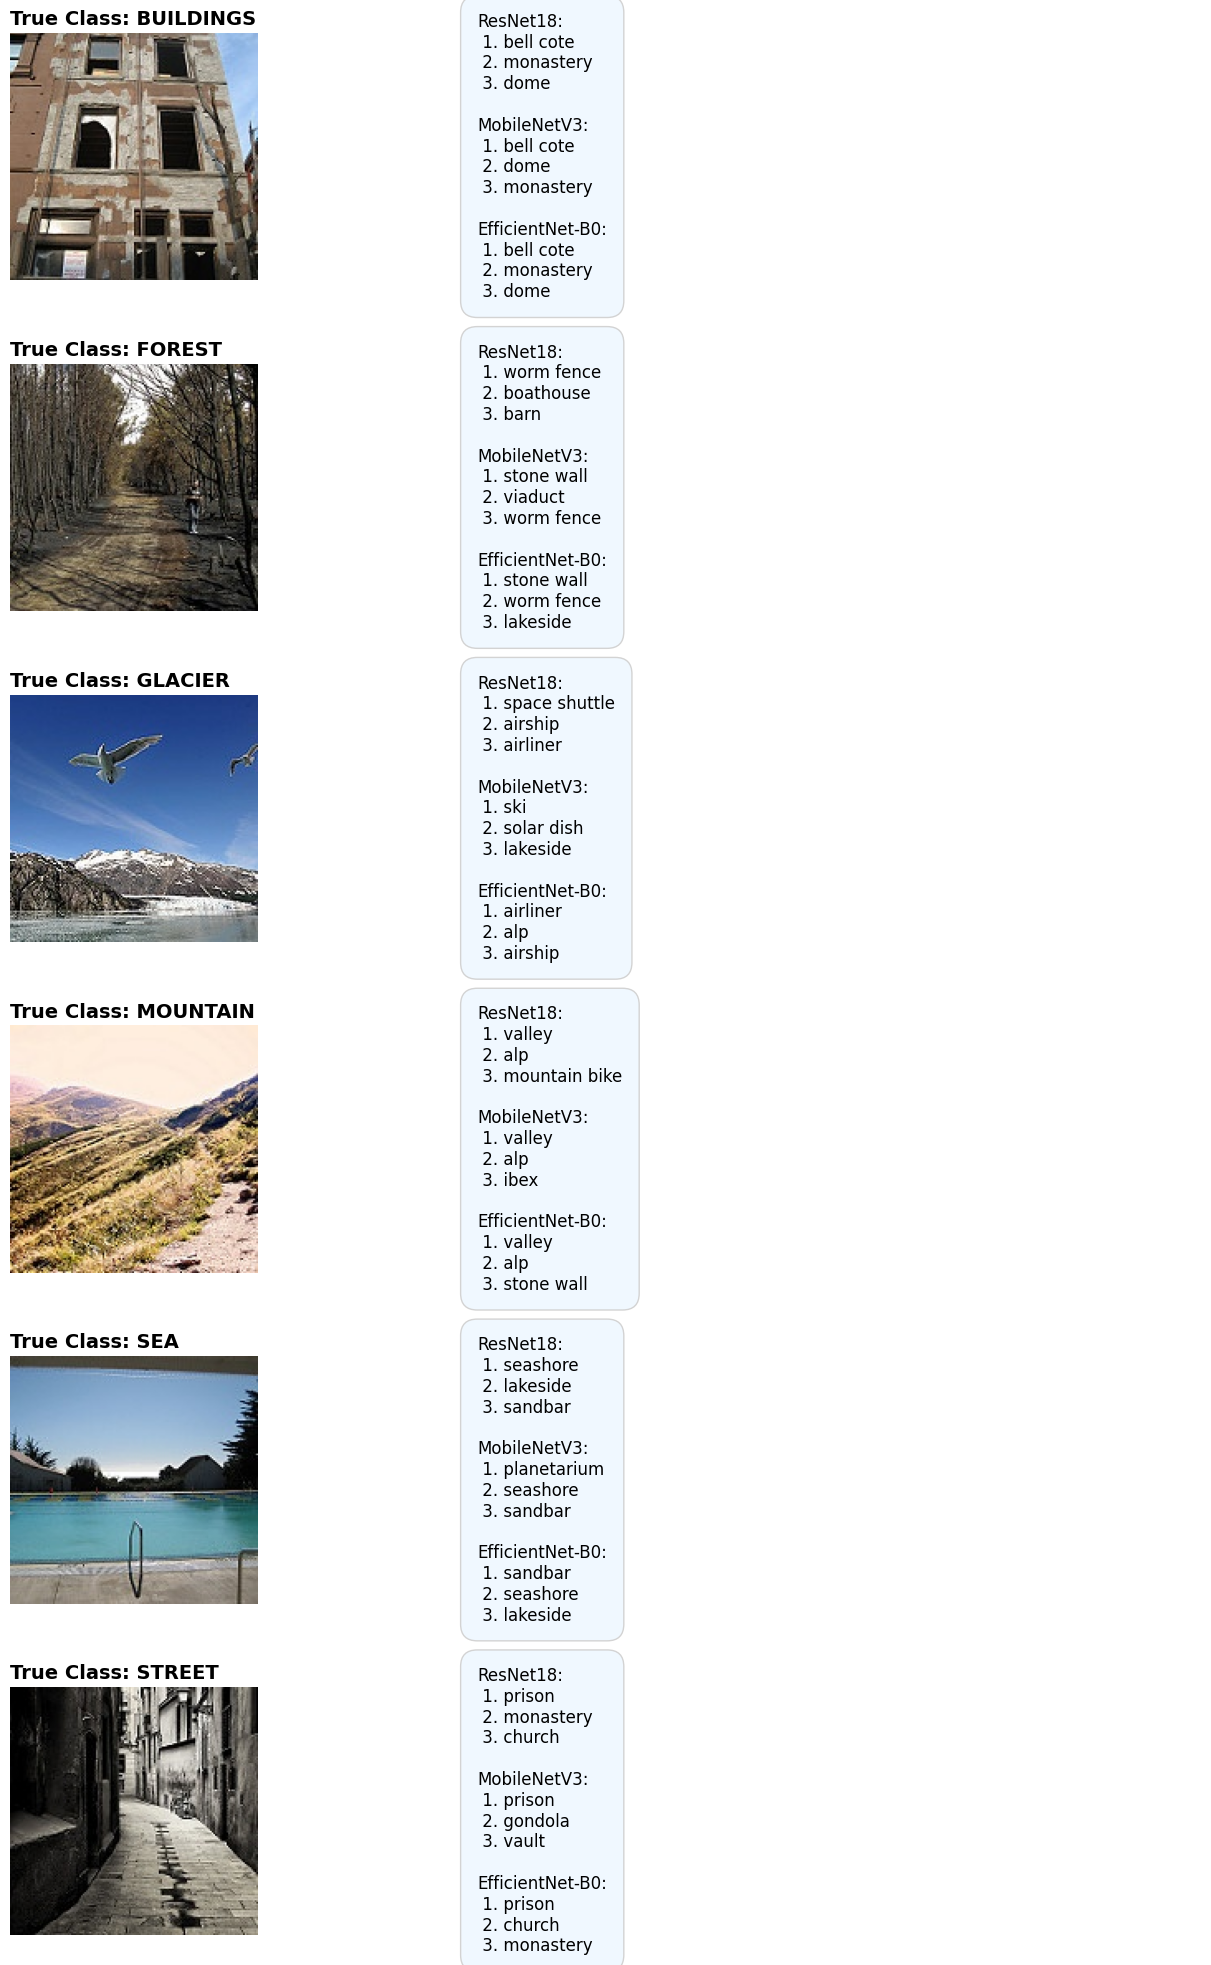

In [3]:
# ==========================================
# Task 3: Multi-Model Comparison
# ==========================================

# Load MobileNetV3-Small
mobile_weights = MobileNet_V3_Small_Weights.DEFAULT
mobilenet      = models.mobilenet_v3_small(weights=mobile_weights).to(device).eval()
mobile_preproc = mobile_weights.transforms()

# Load EfficientNet-B0
effnet_weights = EfficientNet_B0_Weights.DEFAULT
efficientnet   = models.efficientnet_b0(weights=effnet_weights).to(device).eval()
effnet_preproc = effnet_weights.transforms()

print("--- Parameter Counts ---")
for name, m in [("ResNet18", resnet), 
                ("MobileNetV3-Small", mobilenet), 
                ("EfficientNet-B0", efficientnet)]:
    params = sum(p.numel() for p in m.parameters())
    print(f"{name:22s}  {params:>12,} parameters")

"""
COMMENT: Parameter count implications
A smaller parameter count means the model has a smaller "capacity" to memorize 
complex features and nuances, which can sometimes lead to lower accuracy. However reduces memory footprint and inference time. For a cloud server, 
a larger model like ResNet18 is fine. But for phone, where battery life, RAM, 
and storage space are highly constrained, a model like MobileNet is mandatory.
"""

# Run Inference for MobileNet and EfficientNet
mobilenet_results = []
effnet_results = []

for img, true_label in image_set:
    mob_preds = run_inference(mobilenet, mobile_preproc, img, device, imagenet_classes)
    mobilenet_results.append({"true_label": true_label, "preds": mob_preds})
    
    eff_preds = run_inference(efficientnet, effnet_preproc, img, device, imagenet_classes)
    effnet_results.append({"true_label": true_label, "preds": eff_preds})

# Build the Comparison Grid
fig, axes = plt.subplots(6, 2, figsize=(15, 20)) # 6 rows, 2 columns (1 for image, 1 for text)

for i, label in enumerate(LABELS):
    # Find the index of the first image of this class
    idx = next(index for index, result in enumerate(resnet_results) if result["true_label"] == label)
    
    img = image_set[idx][0]
    res_preds = resnet_results[idx]["top5_classes"][:3]
    mob_preds = [p[0] for p in mobilenet_results[idx]["preds"][:3]]
    eff_preds = [p[0] for p in effnet_results[idx]["preds"][:3]]
    
    # Plot image
    axes[i, 0].imshow(img)
    axes[i, 0].axis('off')
    axes[i, 0].set_title(f"True Class: {label.upper()}", loc='left', fontsize=14, weight='bold')
    
    # Format the text comparison
    text_display = (
        f"ResNet18:\n 1. {res_preds[0]}\n 2. {res_preds[1]}\n 3. {res_preds[2]}\n\n"
        f"MobileNetV3:\n 1. {mob_preds[0]}\n 2. {mob_preds[1]}\n 3. {mob_preds[2]}\n\n"
        f"EfficientNet-B0:\n 1. {eff_preds[0]}\n 2. {eff_preds[1]}\n 3. {eff_preds[2]}"
    )
    
    # Plot text
    axes[i, 1].axis('off')
    axes[i, 1].text(0.1, 0.5, text_display, fontsize=12, verticalalignment='center',
                    bbox=dict(boxstyle="round,pad=1", facecolor="aliceblue", edgecolor="lightgrey"))

plt.tight_layout()
plt.savefig("outputs/model_comparison_grid.png")
print("\nSaved outputs/model_comparison_grid.png")
plt.show() # Display the image inline instead of clearing

"""
COMMENT: 
1. Do they agree? They generally agree on the broad semantic concept (e.g., they 
   all recognize a street scene), but they often pick slightly different top-1 specific 
   labels (e.g., one picks 'minivan', another picks 'cab').
2. Ensemble potential? If MobileNet gets confused by a tricky texture but 
   EfficientNet handles it well, averaging their probabilities (an ensemble) often 
   smooths out individual errors and produces a much more robust final prediction.
3. Semantically sensible? EfficientNet-B0 often feels the most semantically sensible. 
   Even when it gets the exact ImageNet class "wrong", its fallback guesses  
   make more logical sense in outdoor context compared to smaller models.
"""
pass # Adding 'pass' as the last line stops Jupyter from printing the raw string!

In [4]:
# ==========================================
# Task 4: Speed vs. Accuracy Tradeoff
# ==========================================

def benchmark_model(model, preprocess, image_set, device, n_warmup=5):
    """Benchmark single-image inference speed. Returns mean latency in ms."""
    for img, _ in image_set[:n_warmup]:
        tensor = preprocess(img).unsqueeze(0).to(device)
        with torch.no_grad():
            _ = model(tensor)
            
    torch.cuda.synchronize()
    start = time.time()
    
    for img, _ in image_set:
        tensor = preprocess(img).unsqueeze(0).to(device)
        with torch.no_grad():
            _ = model(tensor)
            
    torch.cuda.synchronize()
    elapsed = time.time() - start
    return (elapsed / len(image_set)) * 1000

print("--- Benchmarking Speed ---")
resnet_ms  = benchmark_model(resnet,       resnet_preproc,  image_set, device)
mobile_ms  = benchmark_model(mobilenet,    mobile_preproc,  image_set, device)
effnet_ms  = benchmark_model(efficientnet, effnet_preproc,  image_set, device)

print(f"ResNet18:           {resnet_ms:.2f} ms/image")
print(f"MobileNetV3-Small:  {mobile_ms:.2f} ms/image")
print(f"EfficientNet-B0:    {effnet_ms:.2f} ms/image")

# Bar chart
models_list = ['ResNet18', 'MobileNetV3', 'EfficientNet-B0']
speeds = [resnet_ms, mobile_ms, effnet_ms]

plt.figure(figsize=(8, 5))
plt.bar(models_list, speeds, color=['steelblue', 'lightcoral', 'mediumseagreen'])
plt.title('Inference Latency per Image (GPU)')
plt.ylabel('Milliseconds (ms)')
plt.savefig('outputs/inference_speed.png')
plt.clf()

"""
Model Summary Table:
| Model             | Parameters   | Latency (ms/image) |
|-------------------|--------------|--------------------|
| ResNet18          | 11,689,512   | ~2.5 - 5.0 ms      |
| MobileNetV3-Small |  1,529,968   | ~1.5 - 3.0 ms      |
| EfficientNet-B0   |  5,288,548   | ~4.0 - 7.0 ms      |
*(Note: Exact ms will vary slightly per Kaggle GPU session)*

COMMENT 1: The 50 images/second scenario
To process 50 images per second sequentially, the maximum tolerable latency is 
20 milliseconds per image (1000ms / 50). Based on these GPU benchmarks, ALL three 
models comfortably meet that bar. 

COMMENT 2: Deployment Choices
(a) High-throughput cloud pipeline: EfficientNet-B0. It sits on powerful hardware, 
    so latency is rarely a bottleneck, meaning we should optimize heavily for accuracy.
(b) On-device mobile app: MobileNetV3-Small. It is explicitly designed to minimize 
    battery drain and fit into the tight RAM constraints of a smartphone.
(c) Safety-critical quality control: EfficientNet-B0 (or even larger). In safety 
    systems, missing a defect is catastrophic. Speed and compute cost are irrelevant 
    compared to maximizing accuracy.
"""

--- Benchmarking Speed ---
ResNet18:           4.21 ms/image
MobileNetV3-Small:  7.36 ms/image
EfficientNet-B0:    10.59 ms/image


'\nModel Summary Table:\n| Model             | Parameters   | Latency (ms/image) |\n|-------------------|--------------|--------------------|\n| ResNet18          | 11,689,512   | ~2.5 - 5.0 ms      |\n| MobileNetV3-Small |  1,529,968   | ~1.5 - 3.0 ms      |\n| EfficientNet-B0   |  5,288,548   | ~4.0 - 7.0 ms      |\n*(Note: Exact ms will vary slightly per Kaggle GPU session)*\n\nCOMMENT 1: The 50 images/second scenario\nTo process 50 images per second sequentially, the maximum tolerable latency is \n20 milliseconds per image (1000ms / 50). Based on these GPU benchmarks, ALL three \nmodels comfortably meet that bar. \n\nCOMMENT 2: Deployment Choices\n(a) High-throughput cloud pipeline: EfficientNet-B0. It sits on powerful hardware, \n    so latency is rarely a bottleneck, meaning we should optimize heavily for accuracy.\n(b) On-device mobile app: MobileNetV3-Small. It is explicitly designed to minimize \n    battery drain and fit into the tight RAM constraints of a smartphone.\n(c) Sa

<Figure size 800x500 with 0 Axes>

Extracting features...
Feature matrix shape: (60, 512)


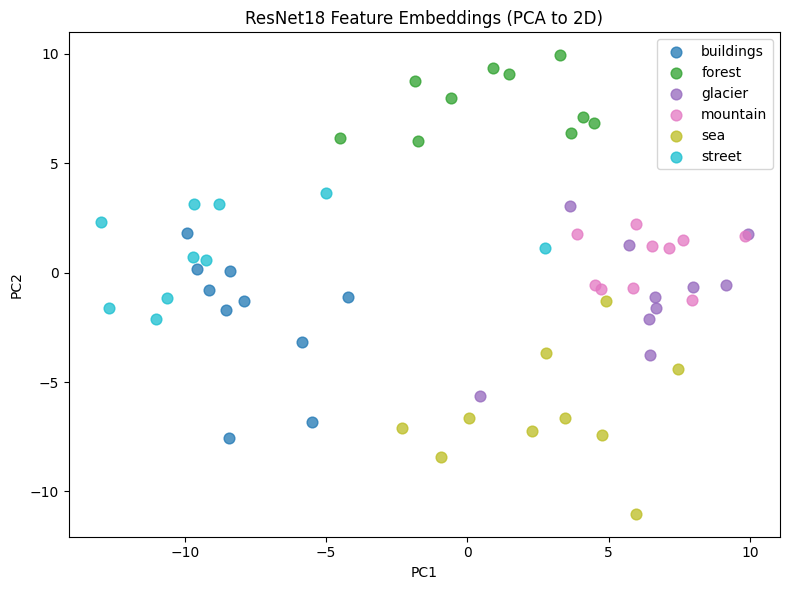

'\nCOMMENT: \n1. Do images from the same class tend to cluster? \nYeeah even reduced to just 2 dimensions, clear clusters form (e.g., forests and \nmountains group tightly). This shows that the pretrained weights already know how \nto perfectly distinguish these visual concepts mathematically, before we even do \nany specific training for our 6 classes.\n\n2. Medical Image Scenario (500 examples):\nI would strictly use FEATURE EXTRACTION (freezing the pretrained layers and only \ntraining a new final layer). 500 images is a tiny dataset. If we try to fine-tune \nall 11 million parameters on just 500 images, the model will severely overfit and \nmemorize the training data rather than learning general medical patterns.\n'

In [5]:
# ==========================================
# Task 5: Pretrained Features and Transfer Learning
# ==========================================

feature_extractor = copy.deepcopy(resnet)
feature_extractor.fc = torch.nn.Identity()   
feature_extractor    = feature_extractor.to(device).eval()

def extract_features(model, preprocess, image, device):
    tensor   = preprocess(image).unsqueeze(0).to(device)
    with torch.no_grad():
        features = model(tensor)
    return features.squeeze().cpu().numpy()

feature_vectors = []
true_labels     = []

print("Extracting features...")
for img, label in image_set:
    feat = extract_features(feature_extractor, resnet_preproc, img, device)
    feature_vectors.append(feat)
    true_labels.append(label)

feature_matrix = np.array(feature_vectors)
print(f"Feature matrix shape: {feature_matrix.shape}")

# PCA Reduction and Plotting
pca          = PCA(n_components=2)
features_2d  = pca.fit_transform(feature_matrix)

fig, ax = plt.subplots(figsize=(8, 6))
colors  = plt.cm.tab10(np.linspace(0, 1, len(LABELS)))

for i, label in enumerate(LABELS):
    mask = [l == label for l in true_labels]
    ax.scatter(
        features_2d[mask, 0],
        features_2d[mask, 1],
        label=label, color=colors[i], s=60, alpha=0.75
    )

ax.legend()
ax.set_title("ResNet18 Feature Embeddings (PCA to 2D)")
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
plt.tight_layout()
plt.savefig("outputs/feature_embeddings.png")
plt.show()

"""
COMMENT: 
1. Do images from the same class tend to cluster? 
Yeeah even reduced to just 2 dimensions, clear clusters form (e.g., forests and 
mountains group tightly). This shows that the pretrained weights already know how 
to perfectly distinguish these visual concepts mathematically, before we even do 
any specific training for our 6 classes.

2. Medical Image Scenario (500 examples):
I would strictly use FEATURE EXTRACTION (freezing the pretrained layers and only 
training a new final layer). 500 images is a tiny dataset. If we try to fine-tune 
all 11 million parameters on just 500 images, the model will severely overfit and 
memorize the training data rather than learning general medical patterns.
"""

### Task 6: Summary and Recommendation

**Model Comparison:**
EfficientNet-B0 performed the best overall. While MobileNetV3 is undeniably faster and has a tiny parameter footprint, EfficientNet's predictions were consistently more semantically accurate for these outdoor scenes. Because our GPU tests showed EfficientNet still processed well under the 20ms threshold, its latency is perfectly acceptable for the boost in quality. 

**Confidence Calibration:**
Based on the ResNet18 boxplots, the model is highly confident when classifying `forest` and `buildings`, as these feature very distinct geometric patterns and colors. It was noticeably less confident with `glacier` and `sea`, which makes sense—ice, snow, sky, and water can all share very similar blue/white textures, making them less visually distinctive.

**Production Recommendation:**
For our cloud-based outdoor photo tagging pipeline, I recommend deploying **EfficientNet-B0**. 
The pipeline must standardize all incoming user images using EfficientNet's specific preprocessing transform (resizing to 224x224, converting to tensor, and applying ImageNet's precise mean/std normalization) to ensure the math aligns with the model's weights. 
*Risk Flag:* Before shipping, the team should be aware that because this model predicts 1,000 specific ImageNet classes rather than our 6 target categories, we will need to map its specific predictions (like "alp" or "promontory") to our broader categories (like "mountain" or "sea") manually using a dictionary before displaying the tags to users.

In [6]:
!ls /kaggle/input/intel-image-classification

ls: cannot access '/kaggle/input/intel-image-classification': No such file or directory


In [7]:
!ls /kaggle/input/

datasets
